## Jobs Dataset:

In this notebook, I explore the data related to job offers available on the platform. It includes data loading, preprocessing, and analysis.

In [1]:
import pandas as pd
import numpy as np
import nltk
import re
from bs4 import BeautifulSoup
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Data Loading:

In [2]:
# Read the raw data
jobs = pd.read_csv('../data/raw/jobs.csv')

In [3]:
# Display the first 5 rows
jobs.head()

,JobID,Title,Description,Requirements,City,State,Country,Zip5,StartDate,EndDate,JobCategoryID,apply_count,hired_count
0,75,Administrative Assistant,The Administrative Assistant must be reliable ...,Please refer to the Job Description to view th...,Houston,TX,US,77036.0,2012-03-30 01:23:57.737,2012-04-29 23:59:59,20,1.0,0.0
1,505,LAB TECH,S. Florida Medical Device Co. seeks QC Lab Tec...,General knowledge of scientific or clinical la...,Plantation,FL,US,33313.0,2012-03-23 04:48:17.063,2012-04-22 23:59:59,137,1.0,1.0
2,764,Travel-Seasonal Staff,<p>Travel-Seasonal Staff </p> <p> CB331736 Ros...,Please refer to the Job Description to view th...,Des Plaines,IL,US,60018.0,2012-03-18 05:19:04.863,2012-04-17 23:59:59,59,1.0,0.0
3,766,MARKETING/ Social Media intern,<p>Marketing Rep </p> <p> CB326227 Chicago </p...,Please refer to the Job Description to view th...,Chicago,IL,US,60606.0,2012-03-22 10:33:46.89,2012-04-21 23:59:59,141,0.0,0.0
4,781,Printing Sales,"<p>Printing Sales Experienced, outside sales w...",Please refer to the Job Description to view th...,Schiller Park,IL,US,60176.0,2012-04-01 01:16:40.797,2012-04-30 23:59:59,4,0.0,0.0


In [4]:
# Description of the dataset
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4291 entries, 0 to 4290
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   JobID          4291 non-null   int64  
 1   Title          4291 non-null   object 
 2   Description    4291 non-null   object 
 3   Requirements   4025 non-null   object 
 4   City           4291 non-null   object 
 5   State          4291 non-null   object 
 6   Country        4291 non-null   object 
 7   Zip5           3096 non-null   float64
 8   StartDate      4291 non-null   object 
 9   EndDate        4291 non-null   object 
 10  JobCategoryID  4291 non-null   int64  
 11  apply_count    4291 non-null   float64
 12  hired_count    4291 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 435.9+ KB


Based on the observations above, I identified missing values, inconsistencies in formatting, and several data types that require modification.

## 2. Data Processing:

In [5]:
# Check duplicated values
duplicate_rows = jobs.duplicated().sum()
print(f"Duplicated rows: {duplicate_rows}")

duplicate_jobid = jobs.duplicated(subset=['JobID']).sum()
print(f"Duplicated JobID rows: {duplicate_jobid}")

Duplicated rows: 0
Duplicated JobID rows: 0


In [6]:
# Convert Zip5 to integer values
jobs["Zip5"] = pd.to_numeric(jobs["Zip5"], errors="coerce")
jobs["Zip5"] = jobs["Zip5"].replace([np.inf, -np.inf], np.nan)
jobs["Zip5"] = jobs["Zip5"].astype("Int64")

In [7]:
# Convert dates to a proper format
jobs['StartDate'] = pd.to_datetime(jobs['StartDate'], errors='coerce')
jobs['EndDate'] = pd.to_datetime(jobs['EndDate'], errors='coerce')

In [8]:
# Check the missing values
jobs.isnull().sum()

JobID               0
Title               0
Description         0
Requirements      266
City                0
State               0
Country             0
Zip5             1195
StartDate          10
EndDate             0
JobCategoryID       0
apply_count         0
hired_count         0
dtype: int64

In [9]:
# Fill the missing values with Not Specified
jobs['Requirements'] = jobs['Requirements'].fillna("Not Specified")

In [10]:
# Fill the missing values with the median
median_zip = int(jobs["Zip5"].median())
jobs["Zip5"] = jobs["Zip5"].fillna(median_zip).astype("Int64")

In [11]:
# Fill the missing values using the EndDate
jobs['StartDate'] = jobs['StartDate'].fillna(jobs['EndDate'] - pd.Timedelta(days=30))

In [12]:
jobs.isnull().sum()

JobID            0
Title            0
Description      0
Requirements     0
City             0
State            0
Country          0
Zip5             0
StartDate        0
EndDate          0
JobCategoryID    0
apply_count      0
hired_count      0
dtype: int64

In this stage, I confirmed that the dataset contains no duplicate records. However, missing values were detected in the Zip5, StartDate, EndDate, and Requirements fields. These values were imputed using median-based or predefined replacement methods.

## 3. Data Cleaning:

In [13]:
# Initialize lemmatizer and load English stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(ENGLISH_STOP_WORDS)

In [14]:
# A function to remove HTML tags
def clean_html(text):
    soup = BeautifulSoup(str(text), "html.parser")
    return soup.get_text(separator=" ")

In [15]:
# A function to clean the text
def clean_text(text):
    # Lowercase
    text = str(text).lower()
    # Remove HTML
    text = clean_html(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(tokens)

In [16]:
# Clean title, description, and requirements
jobs['Title'] = jobs['Title'].apply(clean_text)
jobs['Description'] = jobs['Description'].apply(clean_text)
jobs['Requirements'] = jobs['Requirements'].apply(clean_text)

C:\Users\jawad\AppData\Local\Temp\ipykernel_25568\3468980492.py:3: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(str(text), "html.parser")


In this section, Natural Language Processing techniques were applied to clean and standardize the textual data. These transformations were applied to the job titles, descriptions, and requirements to improve text quality and prepare the data for further analysis.

## 4. Data Analysis:

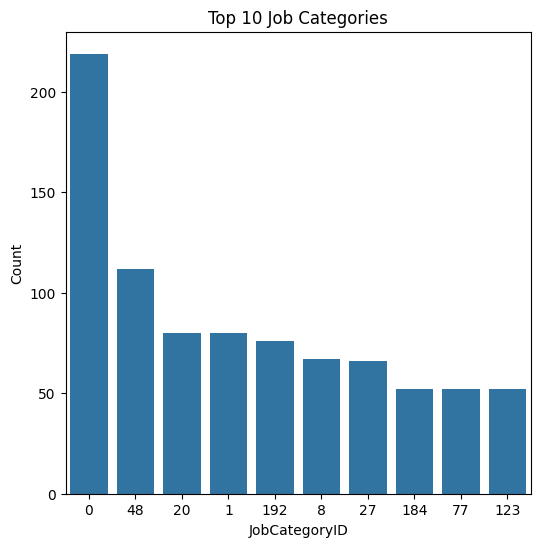

In [17]:
# Top 10 job categories
top_categories = (jobs['JobCategoryID'].value_counts().head(10))
plt.figure(figsize=(6, 6))
sns.barplot(x=top_categories.index.astype(str),y=top_categories.values)
plt.title("Top 10 Job Categories")
plt.xlabel("JobCategoryID")
plt.ylabel("Count")
plt.show()

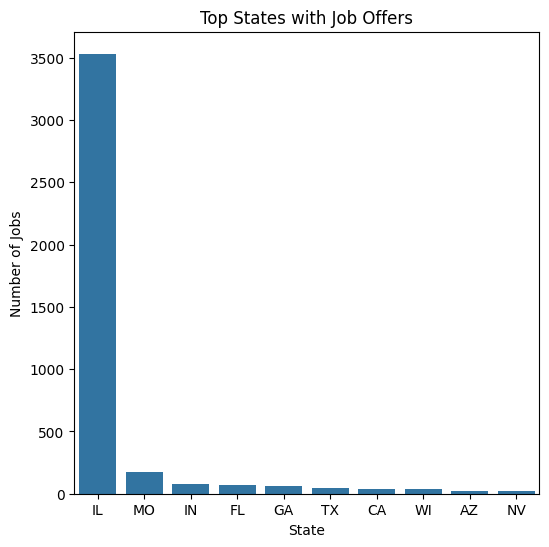

In [18]:
# Top states with job offers
top_states = jobs['State'].value_counts().head(10)
plt.figure(figsize=(6, 6))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top States with Job Offers")
plt.xlabel("State")
plt.ylabel("Number of Jobs")
plt.show()

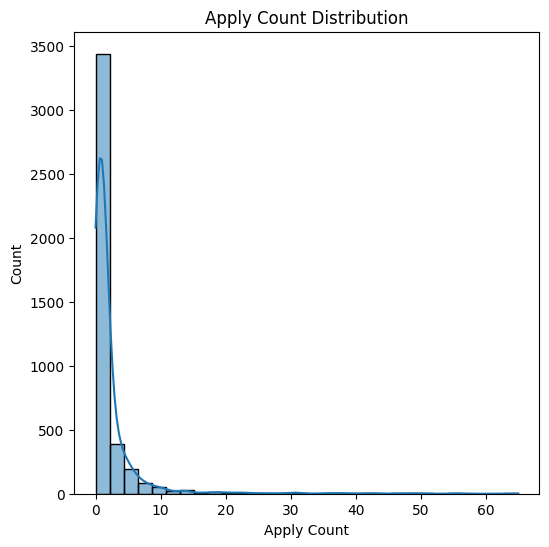

In [19]:
# Apply count distribution
plt.figure(figsize=(6, 6))
sns.histplot(jobs['apply_count'], bins=30, kde=True)
plt.title("Apply Count Distribution")
plt.xlabel("Apply Count")
plt.show()

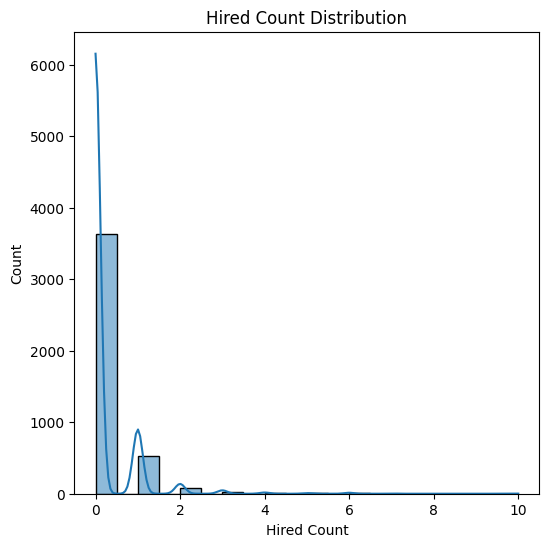

In [20]:
# Hired count distribution
plt.figure(figsize=(6, 6))
sns.histplot(jobs['hired_count'], bins=20, kde=True)
plt.title("Hired Count Distribution")
plt.xlabel("Hired Count")
plt.show()

In [21]:
# Extract year and month
jobs["StartYear"] = jobs["StartDate"].dt.year
jobs["StartMonth"] = jobs["StartDate"].dt.month

In [22]:
# Count jobs per month
monthly_jobs = jobs.groupby("StartMonth").size()

In [23]:
# Convert month numbers to names
monthly_jobs.index = monthly_jobs.index.map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
})

In [24]:
# Sort in correct calendar order
monthly_jobs = monthly_jobs.reindex([
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])

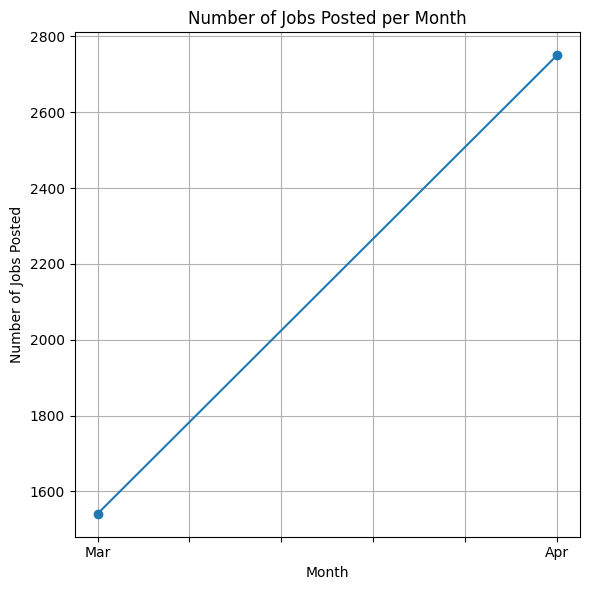

In [25]:
# Number of jobs posted per month
plt.figure(figsize=(6, 6))
monthly_jobs.plot(marker="o")
plt.title("Number of Jobs Posted per Month")
plt.xlabel("Month")
plt.ylabel("Number of Jobs Posted")
plt.grid(True)
plt.tight_layout()
plt.show()

This section presents an exploratory analysis of the dataset through visualizations. The analysis highlights the top job categories, the states with the highest number of job offers, and the distributions of application and hiring counts. Additionally, a time-series analysis was performed to examine the monthly trend in job postings over time.

## 5. Save Cleaned Dataset:

In [26]:
jobs.to_csv("../data/clean/jobs_cleaned.csv", index=False)